# Phase 2: Data Exploration (Per-CSV Workflow)

This notebook implements the Phase 2 exploration plots using one CSV per location/date (no manifest required).

In [5]:
import os
import sys
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import h5py

# Make project-root imports work when notebook is opened from /notebooks
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.noise_profiling import NoiseProfiler

sns.set_theme(style='whitegrid')
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'exploration'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures will be saved to: {OUTPUT_DIR}')

Figures will be saved to: c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\outputs\exploration


In [3]:
# -----------------------------
# User configuration
# -----------------------------
DATA_ROOT = Path(r"C:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\dataset\Skatval")
SESSIONS = ['280126', '230226', '300925']
AUDIO_FOLDERS_BY_SESSION = {
    '280126': [str(DATA_ROOT / '280126')],
    '230226': [str(DATA_ROOT / '230226')],
    '300925': [str(DATA_ROOT / '300925')],
}
SESSION_LABELS = {
    '280126': 'Session 1',
    '230226': 'Session 2',
    '300925': 'Session 3',
}

CSV_GLOB = 'loc_*_*AUTOSAVE*.csv'

sources = []
for session in SESSIONS:
    csvs = sorted(glob.glob(str(DATA_ROOT / session / CSV_GLOB)))
    for csv_path in csvs:
        loc = Path(csv_path).name.split('_')[1]
        sources.append({
            'session': session,
            'location': f'loc_{loc}',
            'csv_path': csv_path,
            'audio_folders': AUDIO_FOLDERS_BY_SESSION[session],
        })

print(f'Found {len(sources)} CSV sources')
pd.DataFrame(sources).head(20)

Found 96 CSV sources


,session,location,csv_path,audio_folders
0,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
1,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
2,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
3,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
4,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
5,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
6,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
7,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
8,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...
9,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,[C:\Users\kampfly\Documents\Ingeborg\Prosjekto...


In [6]:
def to_mel_2d(segment: np.ndarray) -> np.ndarray:
    seg = np.asarray(segment)
    if seg.ndim == 2:
        return seg
    if seg.ndim == 3:
        # Typical shape (C, T, M): average channels
        return np.mean(seg, axis=0)
    raise ValueError(f'Unsupported segment shape: {seg.shape}')

def segment_rms_from_db(segment: np.ndarray) -> float:
    S_db = to_mel_2d(segment)
    power = 10.0 ** (S_db / 10.0)
    return float(np.sqrt(np.mean(power)))

def cache_path_from_csv(csv_path: str, apply_filter: str = 'Unfiltered') -> str:
    return str(Path(csv_path).with_suffix('')) + f'_{apply_filter}.npz'

records = []
source_stats = []

for src in sources:
    cache_path = cache_path_from_csv(src['csv_path'])
    if not os.path.exists(cache_path):
        print(f"Missing cache for {src['csv_path']} -> {cache_path}")
        continue

    with h5py.File(cache_path, 'r') as f:
        y_flat = np.asarray(f['y'][:]).reshape(-1).astype(int)

    n_total = int(len(y_flat))
    n_aircraft = int(np.sum(y_flat == 1))
    n_no_aircraft = int(np.sum(y_flat == 0))

    records.append({
        'session': src['session'],
        'location': src['location'],
        'csv_path': src['csv_path'],
        'cache_path': cache_path,
        'n_total': n_total,
        'n_aircraft': n_aircraft,
        'n_no_aircraft': n_no_aircraft,
    })

    source_stats.append({
        'session': src['session'],
        'location': src['location'],
        'csv_path': src['csv_path'],
        'cache_path': cache_path,
        'y': y_flat,
    })

summary_df = pd.DataFrame(records)
summary_df

,session,location,csv_path,cache_path,n_total,n_aircraft,n_no_aircraft
0,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,16482,8379,8103
1,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,16482,60,16422
2,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,16482,7887,8595
3,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,16482,7989,8493
4,280126,loc_1,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,16482,8095,8387
...,...,...,...,...,...,...,...
91,230226,loc_3,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,15111,284,14827
92,230226,loc_3,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,15111,408,14703
93,230226,loc_3,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,15111,0,15111
94,230226,loc_3,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,C:\Users\kampfly\Documents\Ingeborg\Prosjektop...,15111,10026,5085


In [7]:
# Compute and save noise profiles in a memory-safe way (chunked cache reads)
noise_dir = PROJECT_ROOT / 'history' / 'noise_profiles'
noise_dir.mkdir(parents=True, exist_ok=True)

profiles = {}
batch_size = 512

for session in SESSIONS:
    session_rows = [s for s in source_stats if s['session'] == session]
    if not session_rows:
        profiles[session] = {
            'session_id': session,
            'mean': None, 'std': None, 'median': None, 'p5': None, 'p95': None,
            'n_segments': 0,
            'n_by_location': {},
        }
        continue

    spectra_chunks = []
    n_by_location = {}

    for row in session_rows:
        y = row['y']
        idx_no_air = np.where(y == 0)[0]
        n_by_location[row['location']] = int(len(idx_no_air))
        if len(idx_no_air) == 0:
            continue

        with h5py.File(row['cache_path'], 'r') as f:
            x_dset = f['x']
            for start in range(0, len(idx_no_air), batch_size):
                batch_idx = idx_no_air[start:start + batch_size]
                Xb = x_dset[batch_idx]

                # Average over non-mel axes to get per-segment spectra
                mel_axis = Xb.ndim - 1
                reduce_axes = tuple(ax for ax in range(1, Xb.ndim) if ax != mel_axis)
                Sb = np.mean(Xb, axis=reduce_axes)  # (B, n_mels)
                spectra_chunks.append(Sb.astype(np.float32, copy=False))

    if spectra_chunks:
        S = np.concatenate(spectra_chunks, axis=0)
        profile = {
            'session_id': session,
            'mean': np.mean(S, axis=0),
            'std': np.std(S, axis=0),
            'median': np.median(S, axis=0),
            'p5': np.percentile(S, 5, axis=0),
            'p95': np.percentile(S, 95, axis=0),
            'n_segments': int(S.shape[0]),
            'n_by_location': n_by_location,
        }
    else:
        profile = {
            'session_id': session,
            'mean': None, 'std': None, 'median': None, 'p5': None, 'p95': None,
            'n_segments': 0,
            'n_by_location': n_by_location,
        }

    profiles[session] = profile

    npz_path = noise_dir / f'{session}_noise_profile.npz'
    if profile['n_segments'] > 0:
        np.savez(
            npz_path,
            session_id=session,
            mean=profile['mean'],
            std=profile['std'],
            median=profile['median'],
            p5=profile['p5'],
            p95=profile['p95'],
            n_segments=profile['n_segments'],
        )
    else:
        np.savez(npz_path, session_id=session, n_segments=0)

summary = {
    'sessions': list(SESSIONS),
    'n_segments_by_session': {s: int(profiles[s]['n_segments']) for s in SESSIONS},
    'n_segments_by_location': {s: profiles[s]['n_by_location'] for s in SESSIONS},
}
with open(noise_dir / 'noise_profiles_summary.json', 'w', encoding='utf-8') as f:
    import json
    json.dump(summary, f, indent=2)

print(f'Saved profiles to {noise_dir}')
{k: v['n_segments'] for k, v in profiles.items()}

Saved profiles to c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\history\noise_profiles


{'280126': 571456, '230226': 354775, '300925': 0}

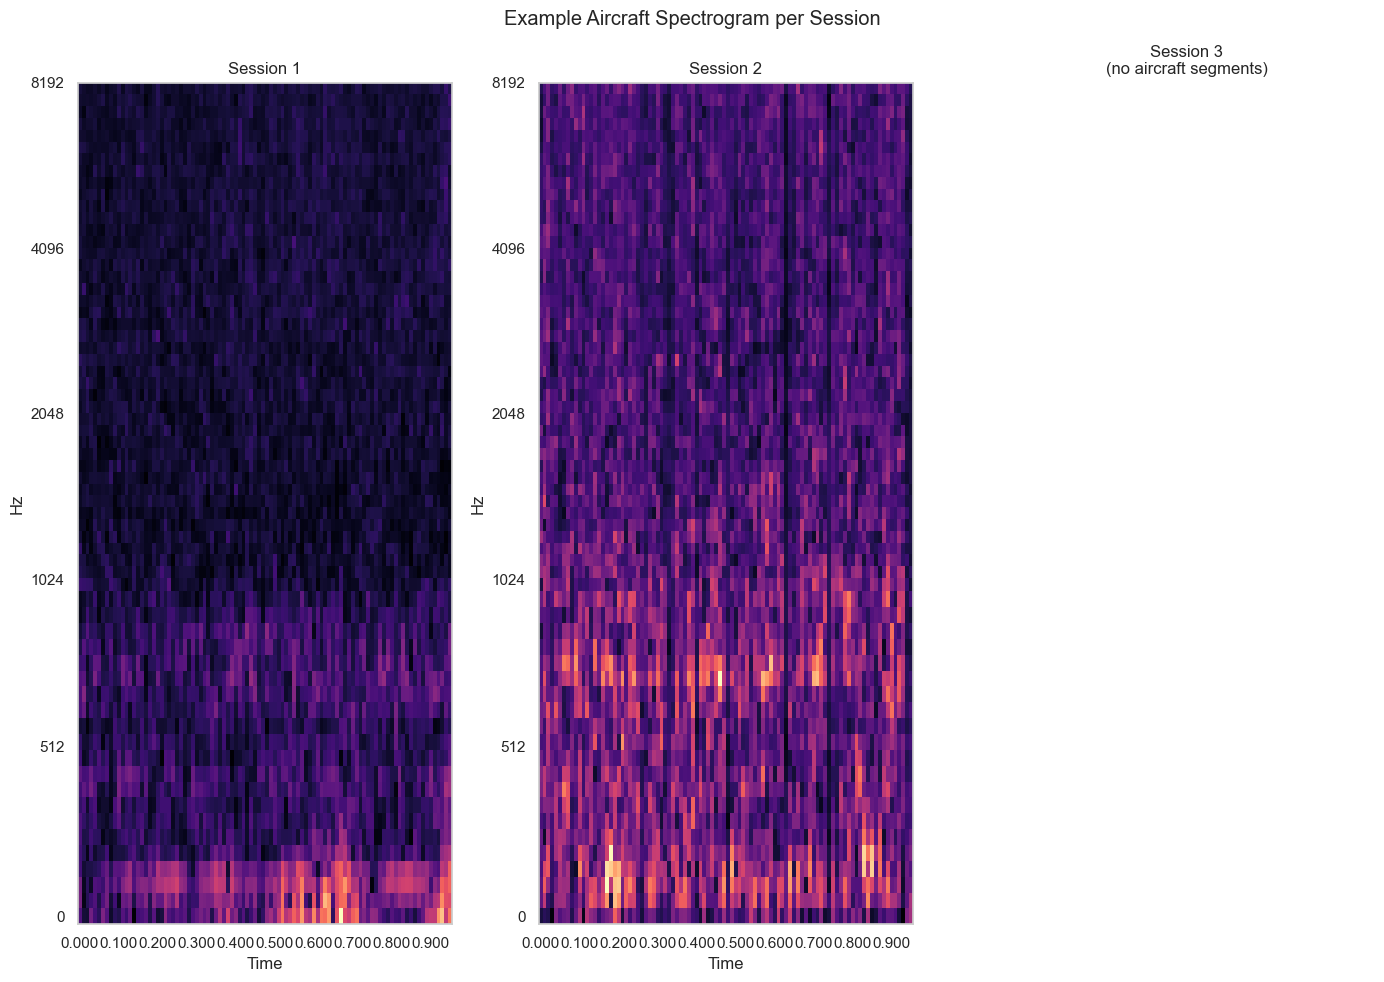

Saved: c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\outputs\exploration\01_example_spectrograms_per_session.png


In [10]:
# 1) Per-session example spectrograms (aircraft)
fig, axes = plt.subplots(1, len(SESSIONS), figsize=(14, 10), squeeze=False)
axes = axes.ravel()

for i, session in enumerate(SESSIONS):
    ax = axes[i]
    session_rows = [s for s in source_stats if s['session'] == session]

    candidates = []
    for row in session_rows:
        idx_air = np.where(row['y'] == 1)[0]
        if len(idx_air) > 0:
            candidates.append((row, idx_air[len(idx_air) // 2]))

    if not candidates:
        ax.set_title(f"{SESSION_LABELS.get(session, session)}\n(no aircraft segments)")
        ax.axis('off')
        continue

    row, mid_idx = candidates[len(candidates) // 2]
    with h5py.File(row['cache_path'], 'r') as f:
        seg = f['x'][int(mid_idx)]

    S = to_mel_2d(seg).T
    librosa.display.specshow(S, x_axis='time', y_axis='mel', sr=16000, hop_length=160, ax=ax)
    ax.set_title(SESSION_LABELS.get(session, session))

fig.suptitle('Example Aircraft Spectrogram per Session')
plt.tight_layout()
out_path = OUTPUT_DIR / '01_example_spectrograms_per_session.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

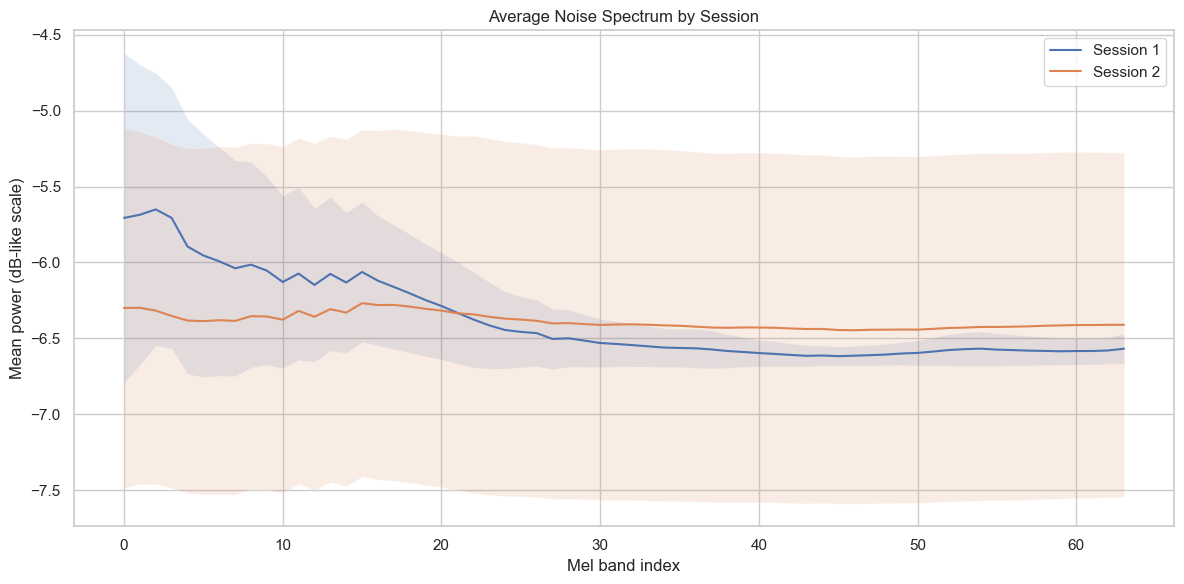

Saved: c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\outputs\exploration\02_noise_profile_overlay.png


In [11]:
# 2) Noise profile comparison (mean +/- std)
plt.figure(figsize=(12, 6))

for session in SESSIONS:
    p = profiles.get(session)
    if not p or p['n_segments'] == 0 or p['mean'] is None:
        continue

    mean_s = np.asarray(p['mean'])
    std_s = np.asarray(p['std'])
    x = np.arange(len(mean_s))
    label = SESSION_LABELS.get(session, session)

    plt.plot(x, mean_s, label=label)
    plt.fill_between(x, mean_s - std_s, mean_s + std_s, alpha=0.15)

plt.xlabel('Mel band index')
plt.ylabel('Mean power (dB-like scale)')
plt.title('Average Noise Spectrum by Session')
plt.legend()
plt.tight_layout()
out_path = OUTPUT_DIR / '02_noise_profile_overlay.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

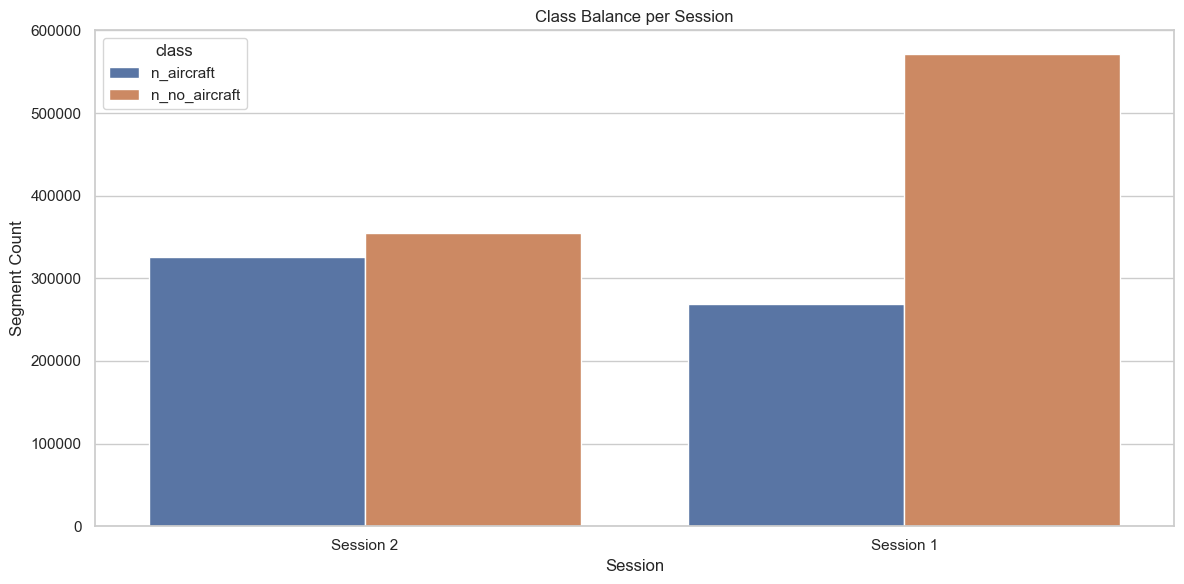

Saved: c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\outputs\exploration\03_class_balance_per_session.png


,session,n_aircraft,n_no_aircraft,session_label
0,230226,325220,354775,Session 2
1,280126,269126,571456,Session 1


In [12]:
# 3) Class balance per session
class_balance = summary_df.groupby('session')[['n_aircraft', 'n_no_aircraft']].sum().reset_index()
class_balance['session_label'] = class_balance['session'].map(lambda s: SESSION_LABELS.get(s, s))

plot_df = class_balance.melt(
    id_vars=['session', 'session_label'],
    value_vars=['n_aircraft', 'n_no_aircraft'],
    var_name='class',
    value_name='count'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='session_label', y='count', hue='class')
plt.xlabel('Session')
plt.ylabel('Segment Count')
plt.title('Class Balance per Session')
plt.tight_layout()
out_path = OUTPUT_DIR / '03_class_balance_per_session.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')
class_balance

In [13]:
# 4) Segment count table per session x location
segment_table = summary_df.pivot_table(
    index='session',
    columns='location',
    values='n_total',
    aggfunc='sum',
    fill_value=0
)
segment_table['Total'] = segment_table.sum(axis=1)
total_row = pd.DataFrame(segment_table.sum(axis=0)).T
total_row.index = ['Total']
segment_table_with_total = pd.concat([segment_table, total_row], axis=0)

segment_table_with_total

location,loc_1,loc_2,loc_3,Total
230226,226665,226665,226665,679995
280126,280194,280194,280194,840582
Total,506859,506859,506859,1520577


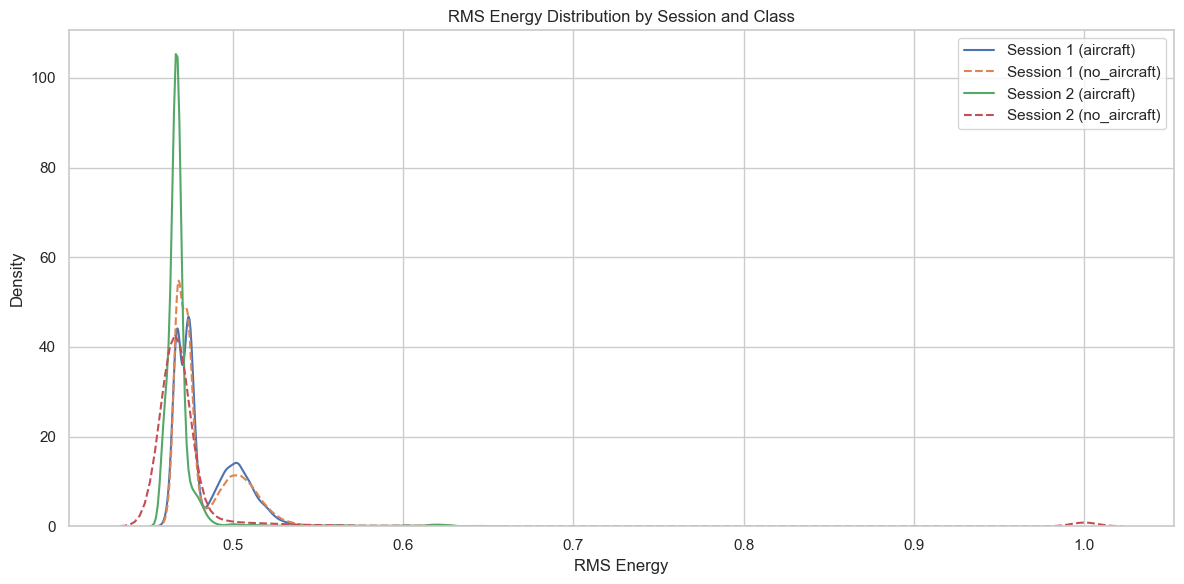

Saved: c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\outputs\exploration\04_rms_energy_distributions.png


,session,session_label,class,rms
0,280126,Session 1,aircraft,0.528998
1,280126,Session 1,aircraft,0.509198
2,280126,Session 1,aircraft,0.539490
3,280126,Session 1,aircraft,0.552439
4,280126,Session 1,aircraft,0.523197


In [15]:
# 5) RMS energy distributions per session (aircraft vs no_aircraft)
rng = np.random.default_rng(42)
MAX_SAMPLES_PER_CLASS_PER_SOURCE = 1200
batch_size = 256

rms_rows = []

for row in source_stats:
    y = row['y']

    class_to_indices = {
        'aircraft': np.where(y == 1)[0],
        'no_aircraft': np.where(y == 0)[0],
    }

    with h5py.File(row['cache_path'], 'r') as f:
        x_dset = f['x']
        for class_name, idx_arr in class_to_indices.items():
            if len(idx_arr) == 0:
                continue

            if len(idx_arr) > MAX_SAMPLES_PER_CLASS_PER_SOURCE:
                idx_arr = rng.choice(idx_arr, size=MAX_SAMPLES_PER_CLASS_PER_SOURCE, replace=False)

            idx_arr = np.asarray(np.sort(idx_arr), dtype=np.int64)

            for start in range(0, len(idx_arr), batch_size):
                batch_idx = idx_arr[start:start + batch_size]
                Xb = x_dset[batch_idx]

                # Convert dB to linear power and compute RMS per segment
                power = 10.0 ** (Xb / 10.0)
                rms_vals = np.sqrt(np.mean(power, axis=tuple(range(1, power.ndim))))

                for rv in rms_vals:
                    rms_rows.append({
                        'session': row['session'],
                        'session_label': SESSION_LABELS.get(row['session'], row['session']),
                        'class': class_name,
                        'rms': float(rv),
                    })

rms_df = pd.DataFrame(rms_rows)

plt.figure(figsize=(12, 6))

# seaborn in this environment does not support `style=` in kdeplot,
# so we draw each group explicitly with class-specific line styles.
class_linestyles = {
    'aircraft': '-',
    'no_aircraft': '--',
}

for session in SESSIONS:
    session_label = SESSION_LABELS.get(session, session)
    for class_name in ['aircraft', 'no_aircraft']:
        subset = rms_df[
            (rms_df['session'] == session) & (rms_df['class'] == class_name)
        ]

        # KDE requires at least 2 samples and non-zero variance.
        if len(subset) < 2 or subset['rms'].nunique() < 2:
            continue

        sns.kdeplot(
            data=subset,
            x='rms',
            common_norm=False,
            bw_adjust=1.0,
            linestyle=class_linestyles[class_name],
            label=f"{session_label} ({class_name})",
        )

plt.xlabel('RMS Energy')
plt.ylabel('Density')
plt.title('RMS Energy Distribution by Session and Class')
plt.legend()
plt.tight_layout()
out_path = OUTPUT_DIR / '04_rms_energy_distributions.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')
rms_df.head()